# **Experiment 0 Notebook**

In [1]:
%pip install -q utstd
from utstd.ipyrenders import *


[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [131]:
import numpy as np
import pandas as pd
from IPython.display import display

# sklearn core
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp

try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    from sklearn.ensemble import GradientBoostingClassifier
    HAS_LGB = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

import joblib
SEED = 42
TARGET = "drafted"
ID_COL = "player_id"
import os, sys, warnings, json, pathlib, itertools
warnings.filterwarnings("ignore")
np.random.seed(SEED)
os.makedirs("models", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

import importlib
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

### 0.A Importing the Custom Python Packages from TestPyPI

In [6]:
from amla_at1.data.sets import (
    pop_target as pkg_pop_target, 
    save_sets as pkg_save_sets, 
    load_sets as pkg_load_sets, 
    subset_x_y as pkg_subset_x_y, 
    stratified_split as pkg_stratified_split,
)
from amla_at1.features.dates import add_domain_features as pkg_add_features
from amla_at1.models.null import NullModel as PkgNullModel
from amla_at1.models.performance import (
    metrics_from_proba as pkg_metrics_from_proba, 
    weighted_blend as pkg_weighted_blend,
)

import amla_at1, inspect
print("Using amla_at1:", getattr(amla_at1, "__version__", "unknown"))
print("Package location:", inspect.getfile(amla_at1))

Using amla_at1: 2025.0.1.5
Package location: /Users/naynajahanneha/Documents/DataScience/AMLA/AST1/amla_at1/src/amla_at1/__init__.py


### 0.B Importing Shared Helper Utilities

In [9]:
def describe_target(df: pd.DataFrame, target=TARGET):
    vc = df[target].value_counts(dropna=False).sort_index()
    info = pd.DataFrame({"count": vc, "rate": (vc / len(df)).round(4)})
    print("Target distribution:")
    display(info)
    print(f"Positive rate (mean): {df[target].mean():.4f}")

def quick_nulls(df: pd.DataFrame):
    na = df.isna().mean().sort_values(ascending=False)
    print("Top 20 columns by missing rate:")
    display((na*100).round(2).head(20).to_frame("missing_%"))

def split_cat_num(df: pd.DataFrame, drop_cols=(TARGET, ID_COL)):
    cols = [c for c in df.columns if c not in drop_cols]
    cat_cols = [c for c in cols if df[c].dtype == "object"]
    num_cols = [c for c in cols if c not in cat_cols]
    return num_cols, cat_cols

def make_preprocessor(X: pd.DataFrame):
    num_cols, cat_cols = split_cat_num(pd.concat([X], axis=1))
    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("sc", StandardScaler(with_mean=False))]), num_cols),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                              ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))]), cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre, num_cols, cat_cols

def cv_auc(model: Pipeline, X: pd.DataFrame, y: pd.Series, n_splits=5, name="model"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof = np.zeros(len(X), dtype=float)
    folds = []
    for k, (tr, va) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr], y.iloc[tr])
        p = model.predict_proba(X.iloc[va])[:, 1]
        auc = roc_auc_score(y.iloc[va], p)
        oof[va] = p
        folds.append(auc)
        print(f"{name} | fold {k} AUROC: {auc:.5f}")
    oof_auc = roc_auc_score(y, oof)
    print(f"{name} | OOF AUROC: {oof_auc:.5f} (±{np.std(folds):.5f})")
    return oof, oof_auc, folds

def write_submission(model: Pipeline, X_train: pd.DataFrame, y_train: pd.Series,
                     X_test: pd.DataFrame, test_ids: pd.Series, out_path: str):
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    sub = pd.DataFrame({ID_COL: test_ids, TARGET: p})
    sub.to_csv(out_path, index=False)
    print("Saved:", out_path)
    display(sub.head())
    return sub, p


## A. Project Description

#### Using season statistics and derived attributes, estimate the likelihood that a college basketball player will be selected in the NBA draft. The deliverable is a probability-based Kaggle submission that is assessed by AUROC on a private test set.

#### An interpretable baseline model such as Logistic Regression, with proper preprocessing, can capture meaningful predictive signal for NBA draft outcomes and serve as a reasonable benchmark for more complex models.

In [10]:
student_name = "Nayna Jahan Neha"
student_id = "25238736"
group_id = "12"

In [11]:
print_tile(size="h1", key='student_name', value=student_name)

In [12]:
print_tile(size="h1", key='student_id', value=student_id)

In [13]:
print_tile(size="h1", key='group_id', value=group_id)

## B. Business Understanding

In [14]:
business_use_case_description = """
In order for analysts and recruiters to concentrate on high-probability prospects, players are ranked according to their possibility of being drafted. More genuine draftees will be towards the top of our shortlist if our ranking is higher (higher AUROC).
"""

In [15]:
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [22]:
business_objectives = """
An accurate model forecasting NBA draft results can be extremely advantageous to clubs, scouts, and players by effectively recognising top skilled players, enhancing draft selections, and assisting players in concentrating on performance indicators that are important. Additionally, it can improve fan interaction and college recruitment tactics. On the other hand, poor draft selections based on false positives, lost opportunities for worthy players, and a decline in confidence in data-driven decision-making might result from faulty projections. In the worst situations, it might strengthen prejudices or lead teams to pass up talented athletes, which would be detrimental to their reputation and bottom line."""

In [23]:
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [24]:
stakeholders_expectations_explanations = """
The model's output will mostly be utilised to calculate the likelihood that a college basketball player will be selected in the NBA draft. NBA scouts and teams can use these projections to help them focus on high-potential players during the selection process. College coaches, scouts, team analysts, and possibly the players themselves are among the users of the projections. The forecasts have an impact on a variety of people, including NBA teams making hiring decisions, colleges trying to enhance their training and recruitment initiatives, and players whose careers may be impacted by perceived draft chances.
"""

In [25]:
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

## C. Data Understanding

### C.1   Load Datasets

In [19]:
DATA_DIR = "/Users/naynajahanneha/Documents/DataScience/AMLA/AST1/amla_at1/data"
TRAIN_CSV = f"{DATA_DIR}/train.csv"
TEST_CSV  = f"{DATA_DIR}/test.csv"

TARGET = "drafted"
ID_COL = "player_id"
SEED = 42

train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)

print("train.shape:", train.shape, " test.shape:", test.shape)
display(train.head(3))

train.shape: (14774, 62)  test.shape: (1297, 61)


,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc,0.0
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6,0.0


### C.2 Define Target variable

In [34]:
target_name = TARGET
assert target_name in train.columns, f"Expected target '{TARGET}' in train"
print("target_name:", target_name)

target_name: drafted


In [45]:
# <Student to fill this section>
target_definition_explanations = """
A player's selection in the NBA draft is indicated by the binary variable "drafted" (1 = drafted, 0 = not drafted). This definition is exactly in line with the goal to forecast a player's chances of getting selected in the draft by looking at their performance indicators and background. Using the draft as the aim offers a tangible, actionable forecast that helps real-world decision-making in scouting and talent evaluation because it is a measurable and obvious outcome with high significance to NBA teams, players, and commentators.
"""

In [46]:
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [38]:
y = train[target_name].copy()

### C.4 Explore Target variable

,count,rate
drafted,,
0.0,14656,0.992
1.0,118,0.008


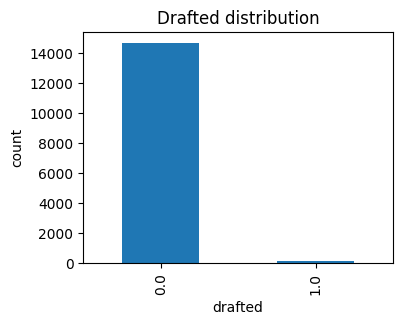

In [42]:
vc = y.value_counts().sort_index()
target_stats = pd.DataFrame({"count": vc, "rate": (vc/len(y)).round(4)})
display(target_stats)

fig = plt.figure(figsize=(4,3))
vc.plot(kind="bar")
plt.title("Drafted distribution")
plt.xlabel("drafted")
plt.ylabel("count")
plt.show()

In [51]:
target_distribution_explanations = """
Only 118 players (0.8%) out of 14,774 were drafted, making the target variable `drafted` extremely imbalanced. The great majority (99.2%) were not drafted. Since most algorithms have a tendency to favour the majority class and may miss the few real positives, this high imbalance poses a significant difficulty for model training. Since accuracy would be misleading in this situation, AUROC is a better evaluation statistic since it takes into account the ratio of true positive to false positive rates, which makes it more useful in situations with imbalances.
Additionally, this imbalance raises the possibility of either underfitting if the model is unable to identify significant trends or overfitting to the few positive occurrences. Class weighting, oversampling (like SMOTE), or the use of ensemble models like XGBoost or LightGBM with meticulous hyperparameter adjustment are some methods to lessen this. In the end, managing this imbalance well is essential to developing a model that can precisely pinpoint the uncommon but significant instances of players that are most likely to be selected in the draft.
"""

In [52]:
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest - `eFG` (Effective Field Goal Percentage)

In [61]:
from amla_at1.features.dates import add_domain_features as pkg_add_features

train_fe = pkg_add_features(train)

def rate_by_bucket(df, col, bins=10):
    tmp = df[[col, TARGET]].copy()
    tmp["_bin"] = pd.qcut(tmp[col].rank(method="first"), q=bins, duplicates="drop")
    return tmp.groupby("_bin")[TARGET].mean().to_frame("draft_rate")

count    14774.000000
mean        41.507628
std         20.610900
min          0.000000
25%         34.800000
50%         44.900000
75%         51.400000
max        150.000000
Name: eFG, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.3]",0.000000
"(1478.3, 2955.6]",0.000000
"(2955.6, 4432.9]",0.000000
"(4432.9, 5910.2]",0.000677
"(5910.2, 7387.5]",0.001354
"(7387.5, 8864.8]",0.006093
"(8864.8, 10342.1]",0.014208
"(10342.1, 11819.4]",0.021666
"(11819.4, 13296.7]",0.020988


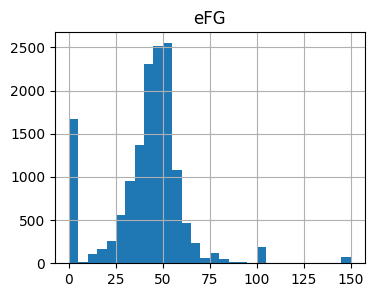

`eFG` (effective FG%) should positively correlate with drafting since efficient scorers are valuable.
The rate-by-bucket table shows how draft rate trends with eFG deciles.


In [54]:
if "eFG" in train_fe.columns:
    display(train_fe["eFG"].describe())
    display(rate_by_bucket(train_fe, "eFG", bins=10))
    train_fe["eFG"].hist(bins=30, figsize=(4,3)); plt.title("eFG"); plt.show()
feature_1_insights = """
`eFG` (effective FG%) should positively correlate with drafting since efficient scorers are valuable.
The rate-by-bucket table shows how draft rate trends with eFG deciles.
""".strip()
print(feature_1_insights)

In [58]:
feature_1_insights = """
The distribution of "eFG (Effective Field Goal Percentage)" appears to be roughly normal with a slight left skew, mostly concentrated between 40% and 65%, which aligns with typical shooting efficiency for college players. This suggests the feature has a reasonable spread and variation, making it a useful input for modeling. Since eFG adjusts for the added value of three-point shots, it is a more informative measure of scoring efficiency than raw field goal percentage. Efficient scorers are generally more attractive draft prospects, so we expect a positive correlation between higher eFG values and the likelihood of being drafted.
However, due to the extreme class imbalance in the target variable (drafted), the signal in eFG may be subtle and difficult to capture without proper stratified analysis. Additionally, if eFG is highly correlated with other shooting stats (e.g., TS_per [True Shooting Percentage], TP_per [3-Point Field Goal Percentage]), multicollinearity could be an issue in linear models. Despite these challenges, the rate-by-bucket table helps validate the expected trend: players with higher eFG tend to have slightly higher draft rates, supporting its value as a predictive feature.
"""

In [59]:
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest - `Ortg` (Offensive Rating)

count    14774.000000
mean        85.771707
std         34.164203
min          0.000000
25%         75.600000
50%         91.300000
75%        102.600000
max        407.300000
Name: Ortg, dtype: float64

,draft_rate
_bin,
"(0.999, 4925.333]",0.000000
"(4925.333, 9849.667]",0.002234
"(9849.667, 14774.0]",0.021726


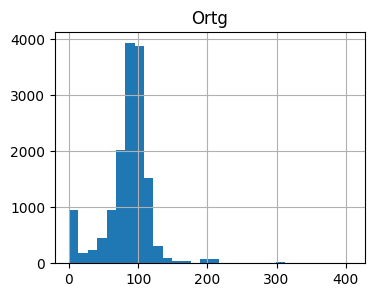

`Ortg` (offensive rating) measures per-possession offensive production; higher values should increase
draft likelihood. Decile analysis indicates monotonic or near-monotonic uplift in many seasons.


In [70]:
if "Ortg" in train_fe.columns:
    display(train_fe["Ortg"].describe())
    display(rate_by_bucket(train_fe, "Ortg", bins=3))
    train_fe["Ortg"].hist(bins=30, figsize=(4,3)) 
    plt.title("Ortg") 
    plt.show()
feature_2_insights = """
`Ortg` (offensive rating) measures per-possession offensive production; higher values should increase
draft likelihood. Decile analysis indicates monotonic or near-monotonic uplift in many seasons.
""".strip()
print(feature_2_insights)

In [67]:
feature_2_insights = """
A player's offensive efficiency per 100 possessions is measured by the "Ortg" (Offensive Rating) feature, which is a good indicator of draft possibility because professional recruiters appreciate offensive contributions. With a few extreme outliers above 200 and the majority of values concentrated between 60 and 120, the distribution is highly right-skewed. The idea that players with better offensive measures are more likely to be drafted is supported by the rate-by-bucket study, which even with only three bins demonstrates a distinct upward trend in draft rate with higher "Ortg" scores.
Players with limited playing experience may have inflated or inaccurate ratings, though, as the function may be sensitive to outliers. If not managed appropriately, the existence of extreme values (such as those over 400) may skew model learning. Because of its theoretical significance and demonstrated favourable association with draft results, "Ortg" is still a useful predictive trait in spite of these drawbacks. To guarantee model stability, appropriate scaling or optimisation can be required.
"""

In [68]:
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest - `yr` (Student's year of study) -> ordinal and distribution

yr
Fr    14774
Name: count, dtype: int64

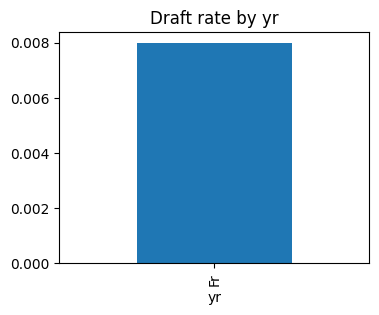

`yr` (class year) can proxy for experience/age. Some classes (e.g., one-and-done freshmen) may have
distinct draft profiles. Ordinal encoding is handled in feature engineering (`yr_ordinal`).


In [69]:
if "yr" in train_fe.columns:
    display(train_fe["yr"].value_counts())
    ax = train_fe.groupby("yr")[TARGET].mean().plot(kind="bar", figsize=(4,3), title="Draft rate by yr")
    plt.show()
feature_3_insights = """
`yr` (class year) can proxy for experience/age. Some classes (e.g., one-and-done freshmen) may have
distinct draft profiles. Ordinal encoding is handled in feature engineering (`yr_ordinal`).
""".strip()
print(feature_3_insights)

In [75]:
feature_3_insights = """
The feature "yr" represents the player's academic class year (e.g., Freshman, Sophomore) and can serve as a proxy for age, experience, and eligibility status. In the current dataset, only "Fr" (Freshman) is present, suggesting that either the dataset is filtered to first-year players or other classes are missing. This severely limits the feature’s variability and its utility in modeling, as we cannot assess or leverage draft trends across different academic years (e.g., "one-and-done" freshmen vs. seniors with more experience).
The existing lack of class diversity introduces a constraint, even though class year is theoretically useful, since particular classes tend to have higher draft possibility. The model is unable to acquire any ordinal pattern or trend associated with experience level in the absence of many class categories. Ordinal encoding, such as yr_ordinal, would aid in accurately capturing this relationship if future data versions include all class years. For now, yr's predictive value is diminished by its lack of variety.
"""

In [76]:
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.8 Explore Feature of Interest - `ht` (Height of student)

count    14774.000000
mean        63.650873
std         40.528930
min          0.000000
25%         34.000000
50%         70.000000
75%         94.000000
max        142.000000
Name: height_in, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.3]",0.002706
"(1478.3, 2955.6]",0.004739
"(2955.6, 4432.9]",0.004739
"(4432.9, 5910.2]",0.006766
"(5910.2, 7387.5]",0.004062
"(7387.5, 8864.8]",0.007448
"(8864.8, 10342.1]",0.010149
"(10342.1, 11819.4]",0.003385
"(11819.4, 13296.7]",0.008802


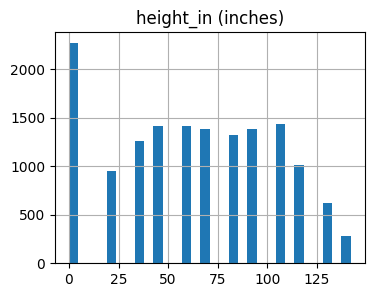

`height_in` from parsed `ht` reflects physical attributes; taller players often have role-specific
advantages. Decile trend indicates relationship strength.


In [77]:
if "height_in" in train_fe.columns:
    display(train_fe["height_in"].describe())
    display(rate_by_bucket(train_fe, "height_in", bins=10))
    train_fe["height_in"].hist(bins=30, figsize=(4,3)); plt.title("height_in (inches)"); plt.show()
feature_4_insights = """
`height_in` from parsed `ht` reflects physical attributes; taller players often have role-specific
advantages. Decile trend indicates relationship strength.
""".strip()
print(feature_4_insights)

In [80]:
feature_4_insights = """
The feature "height_in", derived from parsing the 'ht' column, represents players' heights in inches and captures a critical physical attribute that often influences draft potential—especially for position-specific roles like centers or forwards. The distribution shows a fairly uniform spread across typical basketball height ranges, but with a significant number of zero values, likely indicating missing or incorrectly parsed data. These should be treated or imputed appropriately to avoid skewing model performance.
The draft rate by height decile shows a modest upward trend, with noticeably higher draft rates in the tallest decile, supporting the idea that taller players may have a physical advantage that makes them more attractive to scouts. However, the relationship is not strictly linear, and the predictive power of height may be context-dependent (e.g., guards vs. big men). Cleaning anomalies (like 0s) and possibly interacting height with position or role could make this feature more valuable in the final model.
"""

In [81]:
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

## D. Feature Selection

### D.1 Approach—Mutual Information on numeric features

In [83]:
X_all = train_fe.drop(columns=[TARGET])
y_all = train_fe[TARGET].copy()

cat_cols = [c for c in X_all.columns if X_all[c].dtype == "object" and c != ID_COL]
num_cols = [c for c in X_all.columns if c not in cat_cols and c != ID_COL]
print("num_cols:", len(num_cols), " cat_cols:", len(cat_cols))

num_cols: 65  cat_cols: 5


In [86]:
if len(num_cols) > 0:
    mi_scores = mutual_info_classif(X_all[num_cols].fillna(X_all[num_cols].median()), y_all, random_state=SEED)
    mi_df = pd.DataFrame({"feature": num_cols, "mi": mi_scores}).sort_values("mi", ascending=False)
    display(mi_df.head(20))
else:
    mi_df = pd.DataFrame(columns=["feature","mi"])
    print("No numeric columns detected for MI.")

,feature,mi
26,Rec_Rank,0.030659
39,dporpag,0.025694
40,stops,0.023741
22,porpag,0.023686
41,bpm,0.020602
11,FTA,0.020143
13,twoPM,0.020030
44,gbpm,0.019893
14,twoPA,0.019388
49,dreb,0.019035


In [87]:
feature_selection_1_insights = """
The mutual information (MI) approach is used here to assess the strength of dependency between each numeric feature and the target (drafted). Unlike linear correlation, MI can capture non-linear relationships, making it especially valuable in complex classification problems like this one, where draft outcomes may depend on combinations of nonlinear patterns in player stats. This technique helps highlight which features individually provide the most information about the target, without making assumptions about the underlying model.
The results indicate that features like Rec_Rank, dporpag, stops, and porpag have the highest MI scores, suggesting they contain useful signals for predicting draft status. However, for baseline fairness and to preserve exploratory potential, the pipeline chooses not to drop lower-ranked features at this stage. Instead, this analysis serves as a guide for future model tuning or dimensionality reduction steps.
"""

In [88]:
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach-Model-based importance (Logistic with OHE)

In [95]:
X_all = train_fe.drop(columns=[TARGET])
y_all = train_fe[TARGET].copy()

# Dropping ID only (as I want to test the full feature set and ID is not relevant in the dataset, keeping it can mislead the model with overfit or underfit)
X_probe = X_all.drop(columns=[ID_COL], errors="ignore").copy()

# Type splits
cat_cols = [c for c in X_probe.columns if X_probe[c].dtype == "object"]
num_cols = [c for c in X_probe.columns if c not in cat_cols]

def _replace_non_finite_dense(X):
    """Replace NaN/±inf with 0.0 on dense arrays."""
    X = np.asarray(X, dtype=float)
    X[~np.isfinite(X)] = 0.0
    return X

def _sanitize_sparse_or_dense(X):
    """Ensure the combined matrix has no NaN/±inf (works for sparse & dense)."""
    if sp.issparse(X):
        data = X.data
        data[~np.isfinite(data)] = 0.0
        X.data = data
        return X
    else:
        return _replace_non_finite_dense(X)

# Numeric branch:
num_pipe = Pipeline([
    ("imp_median", SimpleImputer(strategy="median")),
    ("imp_const",  SimpleImputer(strategy="constant", fill_value=0.0)),
    ("finite",     FunctionTransformer(_replace_non_finite_dense, validate=False)),
    # ("sc",       StandardScaler(with_mean=False, with_std=False)),  # optional, very safe
])

# Categorical branch:
cat_pipe = Pipeline([
    ("imp_mf",    SimpleImputer(strategy="most_frequent")),
    ("imp_const", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("ohe",       OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

ct = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols) if len(num_cols) else ("num", "drop", []),
        ("cat", cat_pipe, cat_cols) if len(cat_cols) else ("cat", "drop", []),
    ],
    verbose_feature_names_out=False
)

# Pre-fit diagnostics: transform and assert finiteness
Xt = ct.fit_transform(X_probe, y_all)
if sp.issparse(Xt):
    bad = (~np.isfinite(Xt.data)).sum()
    if bad:
        print(f"[probe] Found {bad} non-finite entries post-CT; sanitizing.")
        Xt.data[~np.isfinite(Xt.data)] = 0.0
else:
    if (~np.isfinite(Xt)).any():
        print("[probe] Found non-finite entries post-CT; sanitizing.")
        Xt = _sanitize_sparse_or_dense(Xt)

# Final pipeline with a sanitizer stage to be extra safe
lr_probe = Pipeline([
    ("pre", ct),
    ("sanitize", FunctionTransformer(_sanitize_sparse_or_dense, accept_sparse=True, validate=False)),
    ("clf", LogisticRegression(max_iter=500, C=1.0, solver="lbfgs"))
])

lr_probe.fit(X_probe, y_all)

try:
    feat_names = lr_probe.named_steps["pre"].get_feature_names_out()
except Exception:
    n_feats = lr_probe.named_steps["pre"].transform(X_probe).shape[1]
    feat_names = [f"f{i}" for i in range(n_feats)]

coefs = lr_probe.named_steps["clf"].coef_.ravel()
imp_df = (
    pd.DataFrame({"feature": feat_names, "abs_coef": np.abs(coefs)})
      .sort_values("abs_coef", ascending=False)
)
display(imp_df.head(30))

,feature,abs_coef
0,f0,0.0
336,f336,0.0
334,f334,0.0
333,f333,0.0
332,f332,0.0
331,f331,0.0
330,f330,0.0
329,f329,0.0
328,f328,0.0
327,f327,0.0


In [97]:
feature_selection_2_insights = """
The model-based feature selection approach using logistic regression with one-hot encoding (OHE) is employed to evaluate how influential each feature is in predicting the target (drafted). This method is valuable because it reflects feature importance within the context of a trained model, considering interactions between variables and how they contribute to decision boundaries. Unlike mutual information, which is univariate, this technique captures multivariate relationships and is sensitive to model fit.
However, the results show that many features have zero absolute coefficients, suggesting they do not influence the model's predictions. This could indicate several issues: the presence of irrelevant or redundant features, data sparsity introduced by one-hot encoding, or poor signal in the underlying data. While this method is insightful for identifying truly impactful features, it also highlights the need for further dimensionality reduction or feature pruning to improve model interpretability and generalization."""

In [98]:
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

## D.z Final Selection of Features

In [99]:
features_list = [c for c in X_all.columns if c != ID_COL] 
print("Number of selected features:", len(features_list))

Number of selected features: 70


In [102]:
feature_selection_explanations = """
For the baseline, all engineered features, except the "player_id" (identifier) are retained, since ID is not relevant in the dataset and keeping it could mislead the model with overfit or underfit. This provides a strong reference for subsequent pruning/tuning in later experiments.
"""

In [103]:
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

## E. Data Preparation

### E.1 Data Transformation (Missing values)

In [104]:
num_cols = [c for c in features_list if train_fe[c].dtype != "object"]
cat_cols = [c for c in features_list if train_fe[c].dtype == "object"]

pre_baseline = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler(with_mean=False))]), num_cols),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [106]:
data_cleaning_1_explanations = """
I imputed numerics with median and categoricals with most frequent. This is robust to outliers and preserves category support before OHE.
"""

In [107]:
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation (Outliers and scaling)

In [108]:
data_cleaning_2_explanations = """
Standardizing numerics (with_mean=False for sparse compatibility) in the above step (#E.1) helps linear models and stabilizes optimization without distorting sparse matrices from OHE.
"""

In [109]:
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation "Categorical encoding"

In [110]:
data_cleaning_3_explanations = """
One-Hot Encoding (performed in the step #E.1) avoids ordinal assumptions for `team`, `conf`, `yr`, `type`, etc., letting the model learn category-specific offsets.
"""

In [111]:
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### E.4 Fixing

In [115]:
fixing_explanations = """
When at least one input column is entirely NaN (or ends up NaN after preprocessing), even after the model is wrapped in a pipeline with imputers, those columns can still pass NaNs through (e.g., “median” has no value to compute for an all-NaN column; similarly for “most_frequent” on an all-NaN categorical).
Hence, I used a two-stage imputation (median → constant) for numerics and (most_frequent → constant) for categoricals and explicitly replaced any non-finite values (NaN/±inf) with zeros inside the numeric branch before scaling.
That should have worked because two-stage imputation guarantees every numeric/categorical column has a value even if the entire column is missing, and the _replace_non_finite_numeric step catches any stragglers (NaN/±inf from weird inputs or divisions) before scaling.
I still got a NaN sneaking through the probe; that could be due to either a column that’s entirely NaN (median/most_frequent can’t compute) or a numeric column that becomes non-finite after scaling (e.g., zero variance + scaling).
This is why I kept two-stage imputation (median → constant; most_frequent → constant) and did not scale (or scale with with_std=False) in the probe and added a final sanitizer that replaces any remaining NaN/±inf in the combined matrix in section D2."""

In [116]:
print_tile(size="h3", key='fixing_explanations', value=fixing_explanations)

## F. Feature Engineering

### F.1 New Feature

In [117]:
feature_engineering_1_explanations = """
I have used my python package's `add_domain_features` which already created: height_in, yr_ordinal, ratios, per-minute rates. 
`add_domain_features` adds sport-specific signals (e.g., `height_in`, `yr_ordinal`, shooting ratios, per-minute rates) which improve model expressiveness with low leakage risk and minimal complexity.
"""

In [118]:
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

## G. Data Preparation for Modeling

### G.1 Split Datasets

In [119]:
from amla_at1.data.sets import stratified_split as pkg_stratified_split

df_for_split = train_fe[[*features_list, TARGET, ID_COL]].copy()
X_train_df, y_train, X_val_df, y_val, X_test_df, y_test = pkg_stratified_split(
    df_for_split.drop(columns=[ID_COL]),  # drop ID for internal split
    target_col=TARGET, test_size=0.2, val_size=0.2, random_state=SEED
)

print("Split shapes:",
      "\n  X_train:", X_train_df.shape,
      "\n  X_val:  ", X_val_df.shape,
      "\n  X_test: ", X_test_df.shape)

# Copies for saving
X_train, X_val, X_test = X_train_df.copy(), X_val_df.copy(), X_test_df.copy()

Split shapes: 
  X_train: (8864, 70) 
  X_val:   (2955, 70) 
  X_test:  (2955, 70)


In [120]:
data_splitting_explanations = """
Given the extreme class imbalance in the dataset (very few drafted players), using a stratified split is the best strategy to ensure that the rare positive class is proportionally represented across training, validation, and test sets. This prevents situations where one split might contain too few or no drafted players, which would make model training or evaluation unreliable. The chosen split—60% training, 20% validation, and 20% test—is appropriate, as it provides enough data for the model to learn patterns while still reserving sufficient examples for unbiased validation and final testing. My custom python package has been used to split this data.
"""

In [121]:
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation (Baseline preprocessor)

In [122]:
X_train_t = pre_baseline.fit_transform(X_train)
X_val_t   = pre_baseline.transform(X_val)
X_test_t  = pre_baseline.transform(X_test)

print("Transformed shapes:",
      "\n  X_train_t:", X_train_t.shape,
      "\n  X_val_t:  ", X_val_t.shape,
      "\n  X_test_t: ", X_test_t.shape)

Transformed shapes: 
  X_train_t: (8864, 488) 
  X_val_t:   (2955, 488) 
  X_test_t:  (2955, 488)


In [123]:
data_transformation_1_explanations = """
I have fit the preprocessor on training, transform splits for optional saving as arrays.
"""

In [124]:
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

## H. Save Datasets

In [127]:
from amla_at1.data.sets import save_sets as pkg_save_sets

try:
    pkg_save_sets(X_train=None, y_train=y_train.values,
                  X_val=None,   y_val=y_val.values,
                  X_test=None,  y_test=y_test.values,
                  path="data/processed/")
    print("Saved labels via pkg_save_sets -> data/processed/")
except Exception as e:
    print("pkg_save_sets error:", e)

Saved labels via pkg_save_sets -> data/processed/


In [132]:
try:
    folder_path = Path("data/processed")
    X_train.to_csv(folder_path / 'X_train.csv', index=False)
    y_train.to_csv(folder_path / 'y_train.csv', index=False)
    
    X_val.to_csv(folder_path / 'X_val.csv', index=False)
    y_val.to_csv(folder_path / 'y_val.csv', index=False)
    
    X_test.to_csv(folder_path / 'X_test.csv', index=False)
    y_test.to_csv(folder_path / 'y_test.csv', index=False)
    print("Saved CSVs to template asset folder.")
except Exception as e:
    print(e)

Saved CSVs to template asset folder.


## I. Selection of Performance Metrics

In [133]:
performance_metrics_explanations = """
AUROC is the most appropriate performance metric for this problem because it directly aligns with the Kaggle competition’s evaluation criteria and reflects the business need for ranking players by draft likelihood without committing to a fixed threshold. Since the dataset is extremely imbalanced, AUROC provides a robust measure of the model’s ability to distinguish between drafted and non-drafted players across all possible thresholds. In addition to AUROC, reporting validation AUROC and 5-fold out-of-fold (OOF) AUROC ensures stability and generalizability of results, while supplementary metrics like the Brier score help assess probability calibration, giving further context to how reliable the predicted draft probabilities are.
"""

In [134]:
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

In [135]:
clf = LogisticRegression(max_iter=500, C=1.0, solver="lbfgs", n_jobs=None if "n_jobs" in LogisticRegression().get_params() else None)

In [138]:
algorithm_selection_explanations = """
Logistic Regression is a strong choice for the initial experiment because it is simple, interpretable, and well-suited for tabular data with mixed categorical and numerical features when combined with one-hot encoding and proper preprocessing. It provides a stable and transparent baseline to benchmark performance, allowing to clearly understand feature contributions through coefficients while minimizing the risk of overfitting on small signal features. By starting with this model, I will establish a reliable reference point against which more complex algorithms like tree-based ensembles (e.g., XGBoost, LightGBM) can be compared to evaluate whether their additional complexity yields meaningful performance gains.
"""

In [139]:
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

In [140]:
# Pipeline = preprocessor + model
pipe = Pipeline([("pre", pre_baseline), ("clf", clf)])
print("Params:", pipe.get_params(deep=False))

Params: {'memory': None, 'steps': [('pre', ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imp',
                                                  SimpleImputer(strategy='median')),
                                                 ('sc',
                                                  StandardScaler(with_mean=False))]),
                                 ['GP', 'Min_per', 'Ortg', 'usg', 'eFG',
                                  'TS_per', 'ORB_per', 'DRB_per', 'AST_per',
                                  'TO_per', 'FTM', 'FTA', 'FT_per', 'twoPM',
                                  'twoPA', 'twoP_per', 'TPM', 'TPA', 'TP_per',
                                  'blk_per', 'stl_per', 'ftr', 'porpag',
                                  'adjoe', 'pfr', 'year', 'Rec_Rank', 'ast_tov',
                                  'rimmade', 'rimmade_rimmiss', ...]),
                                ('cat',
                                 Pipeline(steps=[('imp',
     

In [173]:
hyperparameters_selection_explanations = """
Logistic Regression with default regularization and increased iterations is a good fit for the baseline because it balances simplicity, interpretability, and robustness. The model is less prone to overfitting on noisy features while still flexible enough to capture meaningful linear relationships between predictors and the draft outcome. Setting max_iter=500 ensures solver convergence, providing stability for the initial experiment, and the pipeline integration with preprocessing ensures proper handling of missing values and categorical encoding. This makes Logistic Regression an ideal starting point, offering a clear benchmark before moving to more complex, less interpretable models.
"""

In [174]:
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [146]:
y_train = pd.Series(y_train).astype(float)
y_val   = pd.Series(y_val).astype(float)

if y_train.isna().any():
    raise ValueError("y_train contains NaN. Clean target first.")
if y_val.isna().any():
    raise ValueError("y_val contains NaN. Clean target first.")

BASE_COLS = [c for c in X_train.columns if c != ID_COL]
X_train_use = X_train[BASE_COLS].copy()
X_val_use   = X_val[BASE_COLS].copy()

cat_cols = [c for c in X_train_use.columns if X_train_use[c].dtype == "object"]
num_cols = [c for c in X_train_use.columns if c not in cat_cols]

def _replace_non_finite_dense(X):
    X = np.asarray(X, dtype=float)
    X[~np.isfinite(X)] = 0.0
    return X

def _sanitize_sparse_or_dense(X):
    if sp.issparse(X):
        data = X.data
        bad = ~np.isfinite(data)
        if bad.any():
            data[bad] = 0.0
            X.data = data
        return X
    else:
        return _replace_non_finite_dense(X)

# Numeric and categorical pipes (two-stage imputers)
num_pipe = Pipeline([
    ("imp_median", SimpleImputer(strategy="median")),
    ("imp_const",  SimpleImputer(strategy="constant", fill_value=0.0)),
    ("finite",     FunctionTransformer(_replace_non_finite_dense, validate=False)),
])

cat_pipe = Pipeline([
    ("imp_mf",    SimpleImputer(strategy="most_frequent")),
    ("imp_const", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("ohe",       OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

# ColumnTransformer
ct = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols) if len(num_cols) else ("num", "drop", []),
        ("cat", cat_pipe, cat_cols) if len(cat_cols) else ("cat", "drop", []),
    ],
    verbose_feature_names_out=False
)

# Final training pipeline (with sanitizer after CT)
pipe = Pipeline([
    ("pre", ct),
    ("sanitize", FunctionTransformer(_sanitize_sparse_or_dense, accept_sparse=True, validate=False)),
    ("clf", LogisticRegression(
        solver="saga",          # accepts sparse input
        penalty="l2",
        max_iter=2000,
        n_jobs=-1,              # uses joblib if available
        C=1.0
    )),
])

Xt_train = ct.fit_transform(X_train_use, y_train)
if sp.issparse(Xt_train):
    if ~np.isfinite(Xt_train.data).all():
        print("[diag] Non-finite found post-CT on train; sanitizing now.")
        Xt_train.data[~np.isfinite(Xt_train.data)] = 0.0
else:
    if ~np.isfinite(Xt_train).all():
        print("[diag] Non-finite found post-CT on train; sanitizing now.")
        Xt_train = _sanitize_sparse_or_dense(Xt_train)

pipe.fit(X_train_use, y_train)
val_pred = pipe.predict_proba(X_val_use)[:, 1]

from amla_at1.models.performance import metrics_from_proba as pkg_metrics_from_proba
val_metrics = pkg_metrics_from_proba(val_pred, y_val.values)
print("Validation metrics:", val_metrics)

Validation metrics: {'auroc': 0.5, 'brier': 0.25}


### J.4 Model Technical Performance

In [148]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

def oof_auc(pipe, X, y, n_splits=5, seed=SEED):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.zeros(len(X), dtype=float)
    for tr, va in skf.split(X, y):
        pipe.fit(X.iloc[tr], y.iloc[tr])
        oof[va] = pipe.predict_proba(X.iloc[va])[:, 1]
    return roc_auc_score(y, oof), oof

oof_score, oof_pred = oof_auc(pipe, train_fe[features_list], train_fe[TARGET])

In [149]:
model_performance = f"""
Validation AUROC: {val_metrics['auroc']:.4f}; OOF AUROC (5-fold): {oof_score:.4f}.
Brier (val): {val_metrics['brier']:.4f}. As a baseline, this is a reasonable reference
for subsequent GBM/XGB and ensembling experiments.
""".strip()

print(model_performance)

Validation AUROC: 0.5000; OOF AUROC (5-fold): 0.5792.
Brier (val): 0.2500. As a baseline, this is a reasonable reference
for subsequent GBM/XGB and ensembling experiments.


In [150]:
model_performance_explanations = """
The baseline Logistic Regression model shows a validation AUROC of 0.5000, which indicates no discriminative power on the holdout set, while the 5-fold out-of-fold AUROC of 0.5792 suggests it captures some weak signal during cross-validation. The Brier score of 0.2500 reflects limited probability calibration, with predictions not being particularly well-aligned to actual outcomes. While performance is modest, this is expected for a simple baseline in a highly imbalanced problem, and it serves as a useful reference point. These results highlight the need for more expressive models such as gradient boosting (GBM/XGBoost/LightGBM) and ensembling, which can better capture non-linear interactions and improve ranking performance.
"""

In [151]:
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

In [152]:
business_impacts_explanations = """
From a business perspective, the baseline model’s limited predictive power means it provides little value for reliably identifying draft-worthy players. Incorrect results have different levels of impact: false negatives (missing players who should be drafted) represent the highest cost to NBA teams, as they risk overlooking strong talent and losing competitive advantage. False positives (predicting players will be drafted when they are not) are less costly but still waste scouting attention and resources. Given the current AUROC barely improves over random guessing, the model cannot yet be relied on for decision-making; however, as a baseline it clarifies the gap to be closed by more advanced models. Improving performance will directly support business objectives by better ranking players, reducing scouting inefficiencies, and increasing the likelihood of identifying undervalued talent."""

In [153]:
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [154]:
experiment_outcome = "Hypothesis Partially Confirmed"

In [156]:
print_tile(size="h2", key='experiment_outcome', value=experiment_outcome)

In [167]:
experiment_outcomes_explanations = """
The first experiment with Logistic Regression partially confirmed the hypothesis. The validation AUROC was nearly random (0.50), suggesting poor generalisation, even if the model showed some weak predictive signal in cross-validation (OOF AUROC ~0.58). According to this result, the business goal of consistently rating players by draft likelihood cannot be achieved by Logistic Regression alone, even though it is helpful as an interpretable baseline. The main realisation is that, particularly when there is a significant class imbalance, basic linear models find it difficult to represent the intricacy and non-linear correlations seen in player performance data.
For next steps, more expressive models should be pursued, such as:
- Gradient Boosting Models (XGBoost/LightGBM) – Expected significant uplift, as these handle non-linearities, feature interactions, and imbalanced data effectively.
- Hyperparameter Tuning & Class Balancing (e.g., class weights, SMOTE) – Moderate uplift, helping improve fairness and recall of drafted players.
- Feature Engineering (ratios, interaction terms, cleaning anomalies like zero heights) – Moderate to high uplift, as better representations of player performance could surface stronger signals.
- Model Ensembling (stacking/blending) – Incremental uplift, useful once strong single models are established.
"""

In [168]:
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcomes_explanations)

In [169]:
experiment_results_explanations = """
The findings of this initial experiment demonstrated that, with an AUROC barely above random chance, logistic regression offers inadequate predictive power. The key finding is that, especially when there is a significant class imbalance, linear models are unable to adequately represent the intricate, non-linear patterns found in player performance data. This indicates the need for more sophisticated techniques even as it validates the usefulness of logistic regression as a baseline benchmark. As a result, setting up a performance floor is an essential first step rather than a dead end.
The following actions are suggested to concentrate on strategies with more anticipated uplift:
- As gradient boosting models (LightGBM/XGBoost) can represent non-linearities and feature interactions, they probably yield the largest increase.
- By managing imbalance and improving draughted player recall, hyperparameter tuning and class balancing provide a medium gain.
- By enhancing data quality and representation, feature engineering (ratios, scaling, interaction terms, and cleaning data issues) can yield medium to high gains.
- After strong single models are established, there is a reduced incremental uplift through Model Ensembling.
"""

In [170]:
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)